In [1]:
from collections import Counter
import torch
from torch.nn import CrossEntropyLoss
from torch.utils.data import Subset, WeightedRandomSampler, DataLoader, Dataset
from torchvision import datasets, transforms
import numpy as np
from matplotlib import pyplot as plt

In [2]:
np.random.seed(42)

In [3]:
transform = transforms.ToTensor()

full_trainset = datasets.CIFAR10(root='input_data', train=True, download=True, transform=transform)

targets_all = np.array(full_trainset.targets)

In [4]:
targets_all

array([6, 9, 9, ..., 9, 1, 1], shape=(50000,))

In [5]:
CIFAR10_CLASSES = full_trainset.classes

In [6]:
classes_sizes = [5000, 4000, 2000, 1000, 500, 300, 150, 80, 30, 10]

In [7]:
selected_indices = []

for cls_idx, n in enumerate(classes_sizes):
    idx = np.where(targets_all == cls_idx)[0]
    selected_indices.extend(np.random.choice(idx, size=n, replace=False))

imbalanced_labels = [targets_all[i] for i in selected_indices]
imbalanced_subset = Subset(full_trainset, selected_indices)

In [8]:
counts = Counter(imbalanced_labels)
values = [counts[i] for i in range(10)]

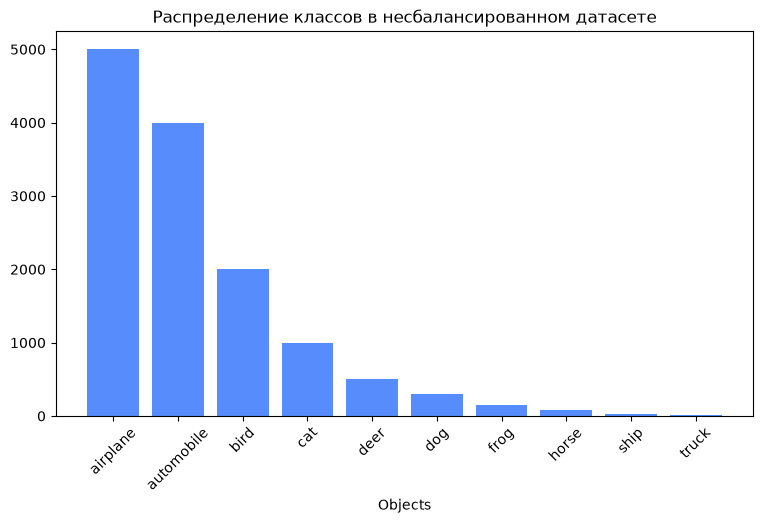

In [9]:
fig, ax = plt.subplots(figsize=(9,5))

ax.bar(CIFAR10_CLASSES, values)
ax.set_xlabel("Objects")
ax.set_title("Распределение классов в несбалансированном датасете")
ax.tick_params(axis='x', rotation=45)


In [10]:
# коэффициент дисбанса
ratio = max(values) / min(values)
print(ratio)

500.0


## oversampling example

In [11]:
# вес класс = 1 / количнство объектов

class_weights_map = {cls: 1.0 / count for cls, count in counts.items() }
sample_weights = [class_weights_map[i] for i in imbalanced_labels]
sample_weights_t = torch.DoubleTensor(sample_weights)

In [12]:
oversampler_one = WeightedRandomSampler(
    weights=sample_weights_t,
    num_samples=len(sample_weights_t),
    replacement=True # разрешаем повторную выборку редких классов
)

In [13]:
balanced_loader_one = DataLoader(imbalanced_subset, batch_size=32, sampler=oversampler_one)

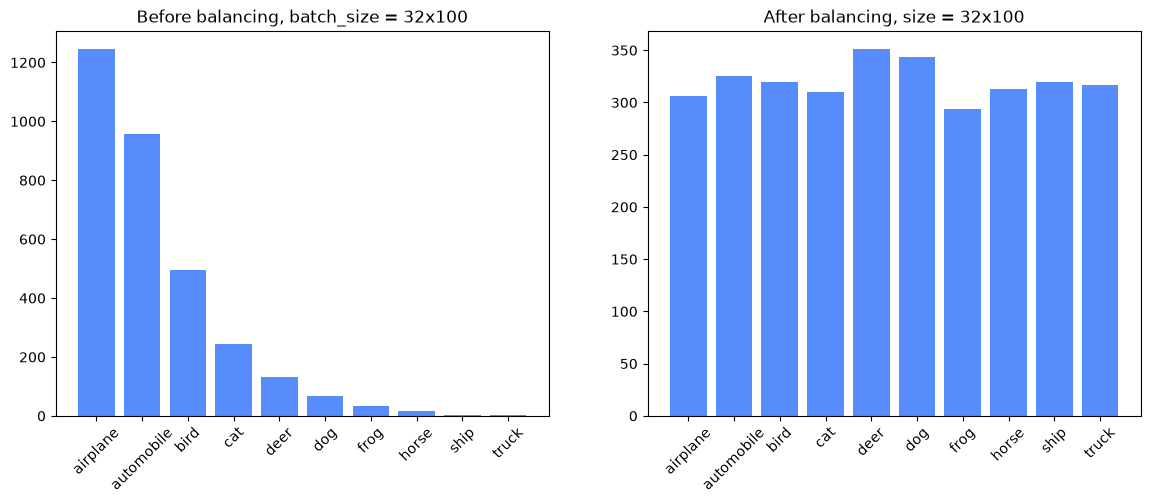

In [14]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

# before
batch_size = 32
raw_loader = DataLoader(imbalanced_subset, batch_size=3200, shuffle=True)
_, raw_lbl = next(iter(raw_loader))
raw_counter = [ Counter(raw_lbl.numpy())[i] for i in range(10) ]
axes[0].bar(CIFAR10_CLASSES, raw_counter)
axes[0].set_title(f"Before balancing, batch_size = {batch_size}x100")
axes[0].tick_params(axis='x', rotation=45)

# after, aggregate befor 100 batches:
all_lbl = []
for i, (_, lbl) in enumerate(balanced_loader_one):
    if i >= 100:
        break
    all_lbl.extend(lbl.numpy())

balanced_counter = [ Counter(all_lbl)[i] for i in range(10) ]

axes[1].bar(CIFAR10_CLASSES, balanced_counter)
axes[1].set_title(f"After balancing, size = {batch_size}x100")
axes[1].tick_params(axis='x', rotation=45)

plt.show()

In [15]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
    # transforms.ToTensor()
])

In [16]:
class AugDataset(Dataset):
    def __init__(self, base_dataset, transform=None):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, label = self.base_dataset[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [17]:
dataset = AugDataset(imbalanced_subset, train_transform)

In [18]:
oversampler_two = WeightedRandomSampler(
    weights=sample_weights_t,
    num_samples=len(dataset),
    replacement=True # разрешаем повторную выборку редких классов
)

balanced_loader_two = DataLoader(dataset, 32, sampler=oversampler_two)

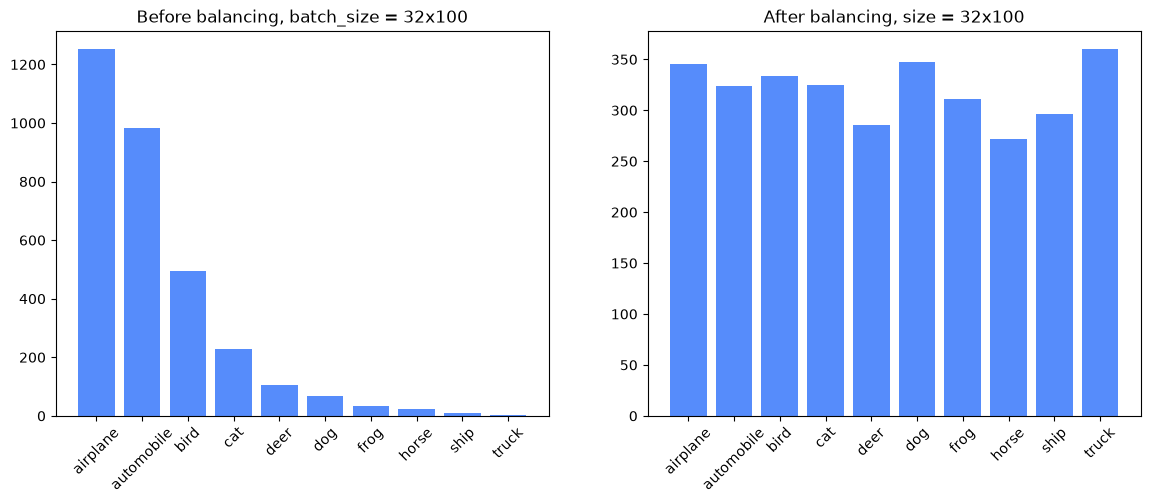

In [19]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

# before
batch_size = 32
raw_loader = DataLoader(imbalanced_subset, batch_size=3200, shuffle=True)
_, raw_lbl = next(iter(raw_loader))
raw_counter = [ Counter(raw_lbl.numpy())[i] for i in range(10) ]
axes[0].bar(CIFAR10_CLASSES, raw_counter)
axes[0].set_title(f"Before balancing, batch_size = {batch_size}x100")
axes[0].tick_params(axis='x', rotation=45)

# after, aggregate befor 100 batches:
all_lbl = []
for i, (_, lbl) in enumerate(balanced_loader_two):
    if i >= 100:
        break
    all_lbl.extend(lbl.numpy())

balanced_counter = [ Counter(all_lbl)[i] for i in range(10) ]

axes[1].bar(CIFAR10_CLASSES, balanced_counter)
axes[1].set_title(f"After balancing, size = {batch_size}x100")
axes[1].tick_params(axis='x', rotation=45)

plt.show()

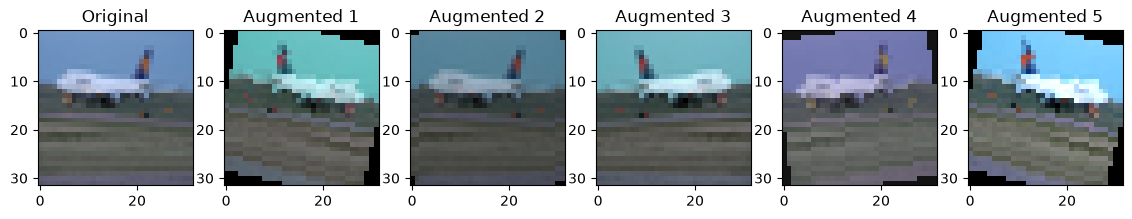

In [20]:
idx = 10

original_img, original_lbl = imbalanced_subset[idx]

fig, axes = plt.subplots(1,6, figsize=(14,5))

# original
axes[0].imshow(original_img.permute(1, 2, 0).numpy())
axes[0].set_title('Original')

for i in range(1, 6):
    aug_image, _ = dataset[idx]

    axes[i].imshow(aug_image.permute(1, 2, 0).numpy())
    axes[i].set_title(f'Augmented {i}')

plt.show()

## undersampling example

In [21]:
target_imb = np.array(imbalanced_labels)

counts = Counter(target_imb)
min_count = min(counts.values())

In [22]:
undersampled_indecies = []

for cls_idx in range(10):
    cls_indecies = np.where(target_imb == cls_idx)[0]

    selected = np.random.choice(
        cls_indecies,
        size=min_count,
        replace=False
    )

    undersampled_indecies.extend(selected)

In [23]:
undersampled_subset = Subset(
    imbalanced_subset,
    undersampled_indecies
)

In [24]:
undersampled_labels = [ imbalanced_labels[i] for i in undersampled_indecies ]

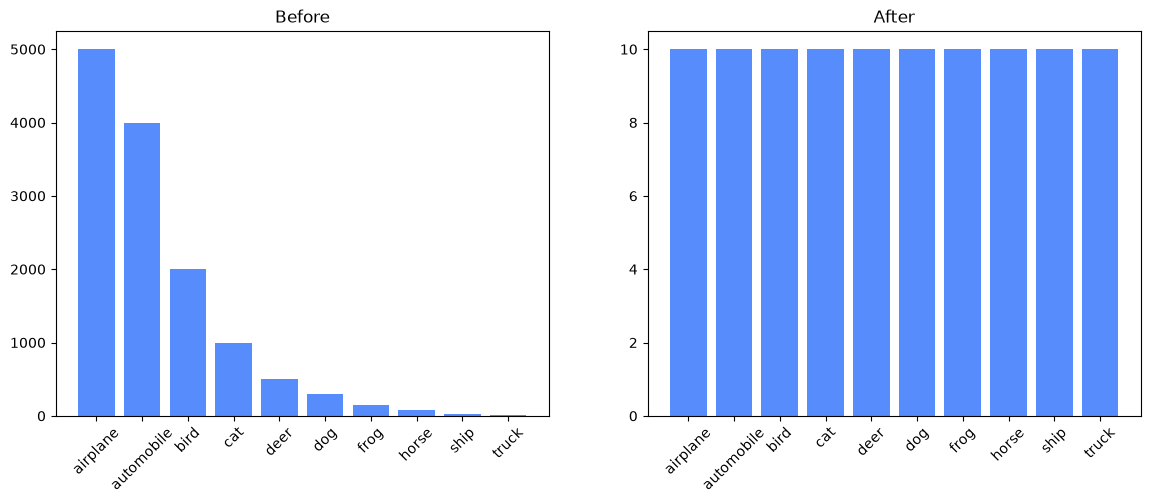

In [25]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

# before
axes[0].bar(CIFAR10_CLASSES, [counts[i] for i in range(10)])
axes[0].set_title("Before")
axes[0].tick_params(axis='x', rotation=45)

# after
axes[1].bar(CIFAR10_CLASSES, [Counter(undersampled_labels)[i] for i in range(10)])
axes[1].set_title("After")
axes[1].tick_params(axis='x', rotation=45)

plt.show()

In [26]:
target_count = 300

undersampled_indecies = []

for cls_idx in range(10):
    cls_indecies = np.where(target_imb == cls_idx)[0]

    if len(cls_indecies) > target_count:
        cls_indecies = np.random.choice(
            cls_indecies,
            size=target_count,
            replace=False
        )

    undersampled_indecies.extend(cls_indecies)

undersampled_subset = Subset(
    imbalanced_subset,
    undersampled_indecies
)

undersampled_labels = [ imbalanced_labels[i] for i in undersampled_indecies ]

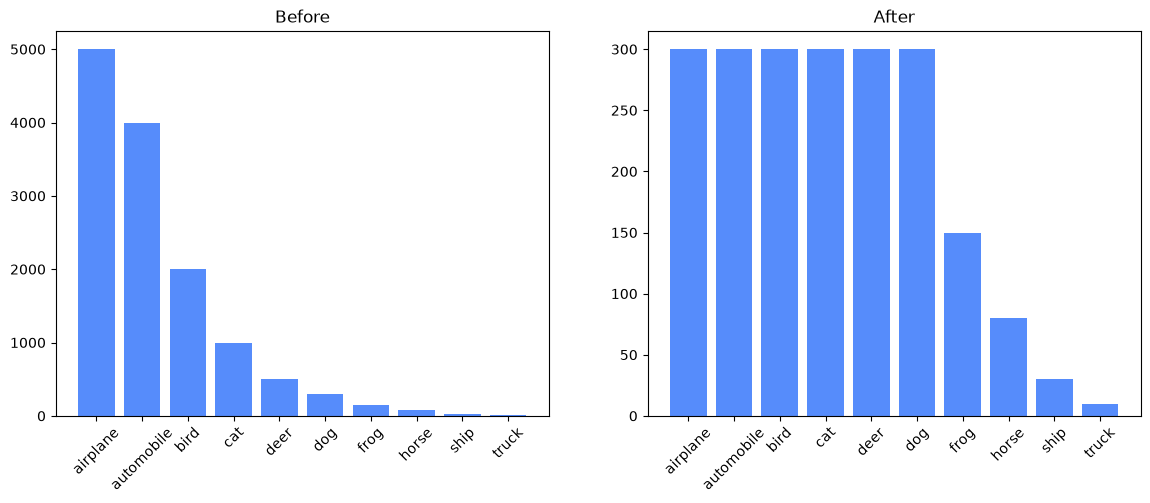

In [27]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

# before
axes[0].bar(CIFAR10_CLASSES, [counts[i] for i in range(10)])
axes[0].set_title("Before")
axes[0].tick_params(axis='x', rotation=45)

# after
axes[1].bar(CIFAR10_CLASSES, [Counter(undersampled_labels)[i] for i in range(10)])
axes[1].set_title("After")
axes[1].tick_params(axis='x', rotation=45)

plt.show()

# Weighted loss

In [28]:
classes_sizes

[5000, 4000, 2000, 1000, 500, 300, 150, 80, 30, 10]

In [29]:
# w_c = N / (K * n_c)
# N - всего объектов, K - число классов, n_c - объектов класса С

clas_count_t = torch.tensor(classes_sizes, dtype=torch.float)
N = clas_count_t.sum()
K = len(classes_sizes)

In [30]:
weights_loss = N / (K * clas_count_t)

In [31]:
for name, n_c, w in zip(CIFAR10_CLASSES, classes_sizes, weights_loss):
    print(f'{name:<12} {n_c:>10} {w:>10.3f}')

# class + counts + weight

airplane           5000      0.261
automobile         4000      0.327
bird               2000      0.654
cat                1000      1.307
deer                500      2.614
dog                 300      4.357
frog                150      8.713
horse                80     16.337
ship                 30     43.567
truck                10    130.700


In [32]:
criterion_weighted = CrossEntropyLoss(weight=weights_loss, reduction='none')
criterion_plain = CrossEntropyLoss(reduction='none')

In [33]:
for cls_idx, cls_name in [(0, 'airplane'), (9, 'truck')]:

    logits = torch.zeros(1, 10)
    logits[0, cls_idx] = 5.0
    target = torch.tensor([cls_idx])

    loss_plain = criterion_plain(logits, target).item()
    loss_weighted = criterion_weighted(logits, target).item()

    print(f'{cls_name:<12} {loss_plain:<10.3f} {loss_weighted:<10.3f}')

airplane     0.059      0.015     
truck        0.059      7.695     
